# Load the data and split it

In [2]:
from helper import get_data, plot_accuracy, plot_loss, plot_confusion_matrix, plot_samples
import matplotlib.pyplot as plt
from keras import layers, models

from helper import plot_accuracy

image_size = (64, 64)

(train_images, test_images, label_names) = get_data(image_size)

print("Number of training batches: ", len(train_images))
print("Number of testing batches: ", len(test_images))
print("Class names: ", label_names)

Found 75000 files belonging to 5 classes.
Using 52500 files for training.
Using 22500 files for validation.
Number of training batches:  410
Number of testing batches:  176
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

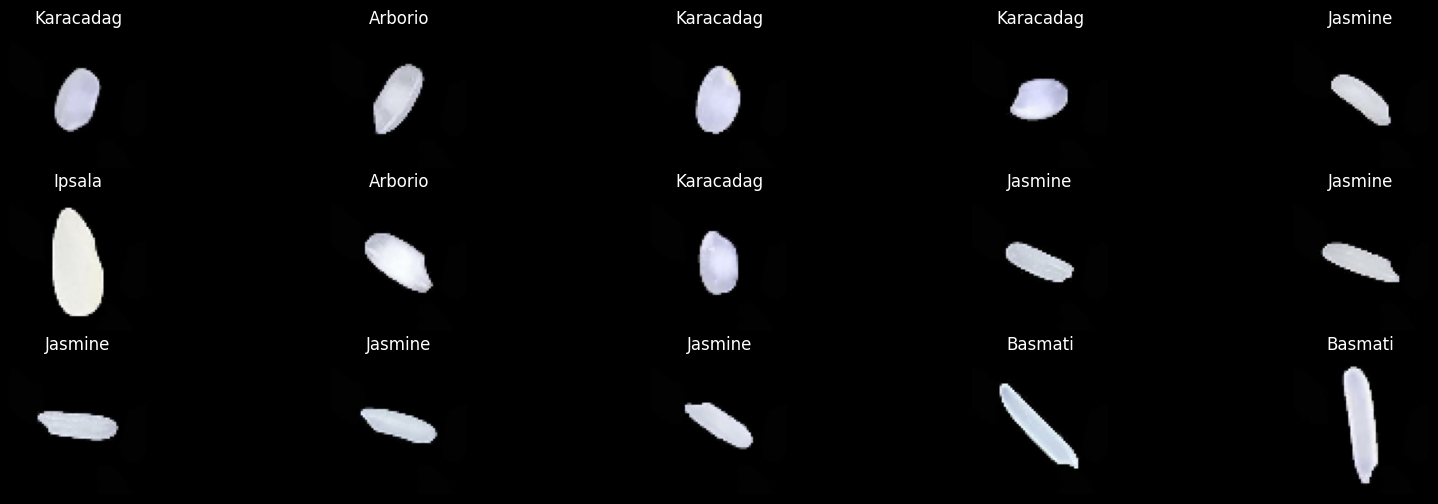

In [2]:
plot_samples(plt, train_images, label_names)

In [3]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973 (7.71 KB)

 Trainable params: 1,973 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [6]:
history = model.fit(train_images, epochs=15, validation_data=test_images)

Epoch 1/3
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.5122 - loss: 3.1799 - val_accuracy: 0.6460 - val_loss: 0.9078
Epoch 2/3
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.7233 - loss: 0.7085 - val_accuracy: 0.7828 - val_loss: 0.5376
Epoch 3/3
410/410 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8109 - loss: 0.4795 - val_accuracy: 0.8414 - val_loss: 0.4036


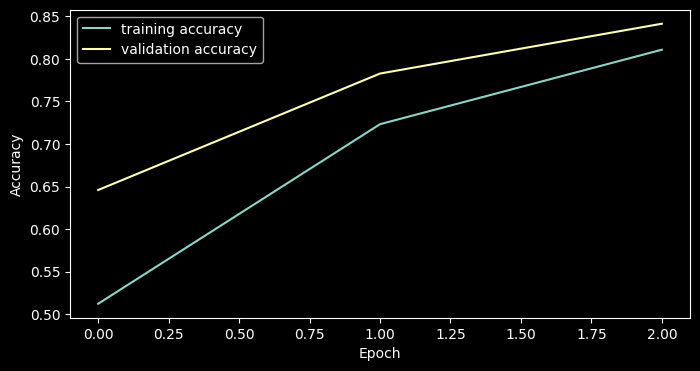

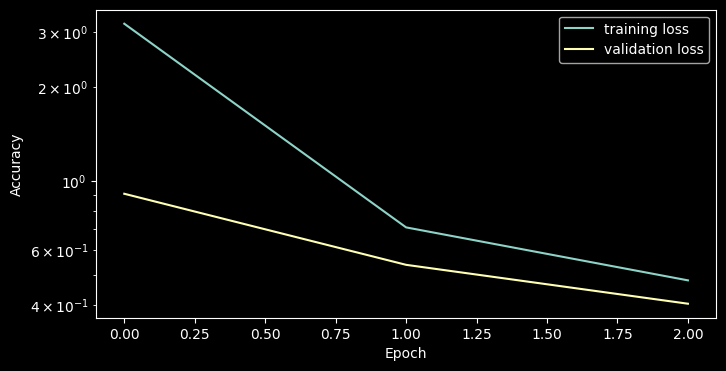

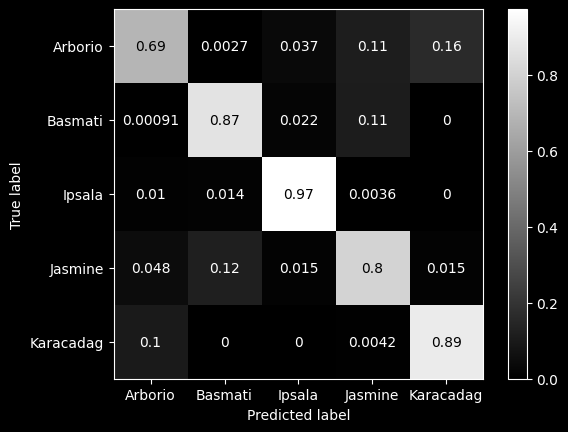

In [9]:
plot_accuracy(plt, history.history["accuracy"], history.history["val_accuracy"])
plot_loss(plt, history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(model, test_images, label_names)